# COMP 469 — Chapter 1: Introduction to AI
## Five-Lab Homework Assignment — Instructor Key

**Estimated completion time:** 3 hours  
**Scope:** Chapter 1 only  
**Format:** Complete all `TODO` cells, run all tests, and answer every reflection question.

This notebook is aligned with *Artificial Intelligence: A Modern Approach*, 4th edition, Chapter 1. It follows the educational style of the official `aimacode/aima-python` repository: readable Python, short experiments, and executable checks.

### Learning outcomes

By the end of this assignment, you should be able to:

1. Distinguish the four approaches to AI.
2. Identify the capabilities required by the standard and Total Turing Tests.
3. Compute expected utility and explain rational choice under uncertainty.
4. Build and analyze a feedback-control system.
5. Demonstrate the value-alignment problem and revise a flawed objective.

### Submission requirements

Submit this completed `.ipynb` file. Before submitting:

- Restart the kernel.
- Run all cells from top to bottom.
- Confirm every assertion passes.
- Leave all outputs visible.
- Answer every reflection prompt in Markdown.

## Lab schedule and grading

| Lab | Topic | Time | Points |
|---|---|---:|---:|
| 1 | Four approaches to AI | 30 minutes | 15 |
| 2 | Standard and Total Turing Tests | 30 minutes | 15 |
| 3 | Rational decisions and expected utility | 40 minutes | 25 |
| 4 | Control theory and cybernetics | 35 minutes | 20 |
| 5 | Value alignment and the King Midas problem | 45 minutes | 25 |
| **Total** |  | **180 minutes** | **100** |

In [1]:
# Run this setup cell first.

from __future__ import annotations

from typing import Dict, Iterable, List, Mapping, Sequence, Tuple
import math
import random

try:
    import matplotlib.pyplot as plt
except ImportError as exc:
    raise ImportError(
        "This notebook requires matplotlib. Install it with: pip install matplotlib"
    ) from exc

random.seed(469)
print("Setup complete.")

Setup complete.


# Lab 1 — The Four Approaches to AI
**Estimated time:** 30 minutes  
**Chapter connection:** Section 1.1

Chapter 1 organizes AI along two dimensions:

- **Thinking** versus **acting**
- **Humanly** versus **rationally**

These dimensions produce four approaches:

1. Thinking humanly
2. Acting humanly
3. Thinking rationally
4. Acting rationally

### Task 1.1

Complete `ai_approach()`.

The function receives two exact strings:

- `focus`: `"thinking"` or `"acting"`
- `standard`: `"humanly"` or `"rationally"`

It must return the corresponding Chapter 1 label.

In [2]:
def ai_approach(focus: str, standard: str) -> str:
    """Return one of the four Chapter 1 approaches to AI."""
    valid_focus = {"thinking", "acting"}
    valid_standard = {"humanly", "rationally"}

    if focus not in valid_focus:
        raise ValueError(f"Invalid focus: {focus}")
    if standard not in valid_standard:
        raise ValueError(f"Invalid standard: {standard}")

    return f"{focus.title()} {standard.title()}"

In [3]:
# Public tests: all must pass.

assert ai_approach("thinking", "humanly") == "Thinking Humanly"
assert ai_approach("acting", "humanly") == "Acting Humanly"
assert ai_approach("thinking", "rationally") == "Thinking Rationally"
assert ai_approach("acting", "rationally") == "Acting Rationally"

try:
    ai_approach("dreaming", "humanly")
    raise AssertionError("Invalid input should raise ValueError.")
except ValueError:
    pass

print("Lab 1.1 tests passed.")

Lab 1.1 tests passed.


### Task 1.2 — Classify systems

For each system below, assign the **single best Chapter 1 approach** and write a one-sentence justification.

| System | Best approach | Justification |
|---|---|---|
| A program that reproduces the sequence and timing of human problem-solving steps | Thinking Humanly | The internal process is compared with human cognition. |
| A chatbot evaluated only by whether judges mistake it for a person | Acting Humanly | Success is based on humanlike observable behavior. |
| A theorem prover that derives valid conclusions from formal premises | Thinking Rationally | The system follows formal laws of correct reasoning. |
| A delivery agent that selects the action with the best expected outcome | Acting Rationally | The system selects the action most likely to achieve its objective. |

### Lab 1 reflection

Answer in 3–5 sentences:

**Why can a system act rationally without thinking humanly?**

> A system can select an effective action without reproducing the mental process a person would use. It may rely on probability, a learned policy, a reflex, or a numerical optimization method. Chapter 1 therefore treats rational action as broader than humanlike thought.

# Lab 2 — Standard and Total Turing Tests
**Estimated time:** 30 minutes  
**Chapter connection:** Section 1.1.1

The standard Turing Test requires:

- Natural language processing
- Knowledge representation
- Automated reasoning
- Machine learning

The Total Turing Test adds:

- Computer vision and speech recognition
- Robotics

In [4]:
STANDARD_TURING_CAPABILITIES = {
    "natural_language_processing",
    "knowledge_representation",
    "automated_reasoning",
    "machine_learning",
}

TOTAL_TURING_ADDITIONS = {
    "computer_vision_and_speech_recognition",
    "robotics",
}

### Task 2.1

Complete `turing_readiness()`.

Return:

- `"Total Turing Test Ready"` when all six capabilities are present.
- `"Standard Turing Test Ready"` when only the four standard capabilities are guaranteed.
- `"Not Ready"` otherwise.

In [5]:
def turing_readiness(capabilities: Iterable[str]) -> str:
    """Classify a system's Turing Test readiness."""
    capability_set = set(capabilities)
    total_requirements = STANDARD_TURING_CAPABILITIES | TOTAL_TURING_ADDITIONS

    if total_requirements.issubset(capability_set):
        return "Total Turing Test Ready"
    if STANDARD_TURING_CAPABILITIES.issubset(capability_set):
        return "Standard Turing Test Ready"
    return "Not Ready"

In [6]:
standard_system = set(STANDARD_TURING_CAPABILITIES)
total_system = standard_system | TOTAL_TURING_ADDITIONS
language_only = {"natural_language_processing", "machine_learning"}

assert turing_readiness(standard_system) == "Standard Turing Test Ready"
assert turing_readiness(total_system) == "Total Turing Test Ready"
assert turing_readiness(language_only) == "Not Ready"

print("Lab 2.1 tests passed.")

Lab 2.1 tests passed.


### Task 2.2 — Capability audit

A proposed robot has the following abilities:

```text
natural_language_processing
knowledge_representation
automated_reasoning
machine_learning
robotics
```

1. What classification does your function return?
2. Which exact capability is missing?
3. Why does that missing capability matter for the Total Turing Test?

> The function returns `Standard Turing Test Ready`. The missing capability is `computer_vision_and_speech_recognition`. It matters because the Total Turing Test requires the machine to perceive people and objects in the physical world, not only communicate and act.

### Lab 2 reflection

Answer in 3–5 sentences:

**Would passing the Total Turing Test prove that a machine understands, is conscious, or thinks exactly like a human? Explain using Chapter 1.**

> No. Passing would show that the system's observable communication, perception, and action were difficult to distinguish from human behavior. Chapter 1 does not claim that this proves consciousness, genuine understanding, or an identical internal thought process.

# Lab 3 — Rational Decisions and Expected Utility
**Estimated time:** 40 minutes  
**Chapter connection:** Sections 1.1.4 and 1.2.3

A rational agent chooses the action that produces the best outcome or, under uncertainty, the **best expected outcome**.

For an action with possible outcomes:

\[
EU(action)=\sum_i P(outcome_i)\times U(outcome_i)
\]

The probabilities should sum to 1.0.

### Task 3.1

Complete `expected_utility()`.

Each outcome is a pair:

```python
(probability, utility)
```

Requirements:

- Reject an empty list.
- Reject probabilities outside `[0, 1]`.
- Reject probability totals that are not approximately `1.0`.
- Return the expected utility.

In [7]:
Outcome = Tuple[float, float]

def expected_utility(outcomes: Sequence[Outcome]) -> float:
    """Compute expected utility for one action."""
    if not outcomes:
        raise ValueError("At least one outcome is required.")

    probability_total = 0.0
    total = 0.0
    for probability, utility in outcomes:
        if not 0.0 <= probability <= 1.0:
            raise ValueError("Each probability must be between 0 and 1.")
        probability_total += probability
        total += probability * utility

    if not math.isclose(probability_total, 1.0, abs_tol=1e-9):
        raise ValueError("Probabilities must sum to 1.0.")
    return total

In [8]:
assert math.isclose(
    expected_utility([(1.0, 5.0)]),
    5.0,
)

assert math.isclose(
    expected_utility([(0.5, 10.0), (0.5, 0.0)]),
    5.0,
)

try:
    expected_utility([(0.8, 10.0), (0.8, -5.0)])
    raise AssertionError("Probabilities that do not sum to 1 should fail.")
except ValueError:
    pass

print("Lab 3.1 tests passed.")

Lab 3.1 tests passed.


### Task 3.2 — Select the rational action

The agent must choose among three actions:

- **Safe:** guaranteed utility of 6
- **Risky:** 60% chance of utility 12, 40% chance of utility 0
- **Reckless:** 20% chance of utility 30, 80% chance of utility -4

Complete `choose_rational_action()` so it returns the action with the highest expected utility.

In [9]:
ACTIONS: Dict[str, List[Outcome]] = {
    "Safe": [(1.0, 6.0)],
    "Risky": [(0.60, 12.0), (0.40, 0.0)],
    "Reckless": [(0.20, 30.0), (0.80, -4.0)],
}

def choose_rational_action(
    actions: Mapping[str, Sequence[Outcome]]
) -> Tuple[str, Dict[str, float]]:
    """Return the best action and expected utilities."""
    if not actions:
        raise ValueError("At least one action is required.")
    utilities = {
        action: expected_utility(outcomes)
        for action, outcomes in actions.items()
    }
    best_action = max(utilities, key=utilities.get)
    return best_action, utilities

In [10]:
best_action, utilities = choose_rational_action(ACTIONS)

print("Expected utilities:")
for action, value in utilities.items():
    print(f"  {action}: {value:.2f}")

print(f"Rational choice: {best_action}")

assert best_action == "Risky"
assert math.isclose(utilities["Safe"], 6.0)
assert math.isclose(utilities["Risky"], 7.2)
assert math.isclose(utilities["Reckless"], 2.8)

print("Lab 3.2 tests passed.")

Expected utilities:
  Safe: 6.00
  Risky: 7.20
  Reckless: 2.80
Rational choice: Risky
Lab 3.2 tests passed.


### Task 3.3 — Limited rationality

Suppose the agent has only enough time to evaluate the first two actions: `Safe` and `Risky`.

1. What action would it select?
2. Is that action rational given its computational limit?
3. Explain why a rational decision can still lead to a bad actual outcome.

> It would select `Risky`, because its expected utility of 7.2 exceeds `Safe` at 6.0. That is rational relative to the actions it had time to evaluate. The actual risky outcome could still be 0, showing that a rational decision under uncertainty can lead to a poor result.

# Lab 4 — Control Theory and Cybernetics
**Estimated time:** 35 minutes  
**Chapter connection:** Section 1.2.7

A feedback-controlled system repeatedly:

1. Senses the current state.
2. Compares it with the desired state.
3. Computes an error.
4. Adjusts its behavior.

You will create a simplified thermostat controller.

### Task 4.1

Complete `control_signal()`.

Use proportional feedback:

```text
signal = gain × (target - current)
```

Clamp the returned signal to the interval `[-max_power, max_power]`.

In [11]:
def control_signal(
    current: float,
    target: float,
    gain: float = 0.6,
    max_power: float = 3.0,
) -> float:
    """Return a bounded heating/cooling signal."""
    error = target - current
    raw_signal = gain * error
    return max(-max_power, min(max_power, raw_signal))

In [12]:
assert math.isclose(control_signal(18, 22, gain=0.5, max_power=3), 2.0)
assert math.isclose(control_signal(30, 22, gain=0.5, max_power=3), -3.0)
assert math.isclose(control_signal(22, 22), 0.0)

print("Lab 4.1 tests passed.")

Lab 4.1 tests passed.


### Task 4.2

Complete `simulate_room()`.

At each step:

1. Get the controller signal.
2. Apply heat loss toward the outside temperature.
3. Update the room temperature.
4. Record the new temperature.

In [13]:
def simulate_room(
    initial_temperature: float,
    target_temperature: float,
    outside_temperature: float,
    steps: int = 40,
    gain: float = 0.6,
    heat_loss: float = 0.08,
) -> List[float]:
    """Simulate a room controlled by feedback."""
    temperatures = [float(initial_temperature)]
    for _ in range(steps):
        current = temperatures[-1]
        signal = control_signal(
            current=current,
            target=target_temperature,
            gain=gain,
        )
        environmental_change = heat_loss * (
            outside_temperature - current
        )
        new_temperature = current + signal + environmental_change
        temperatures.append(new_temperature)
    return temperatures

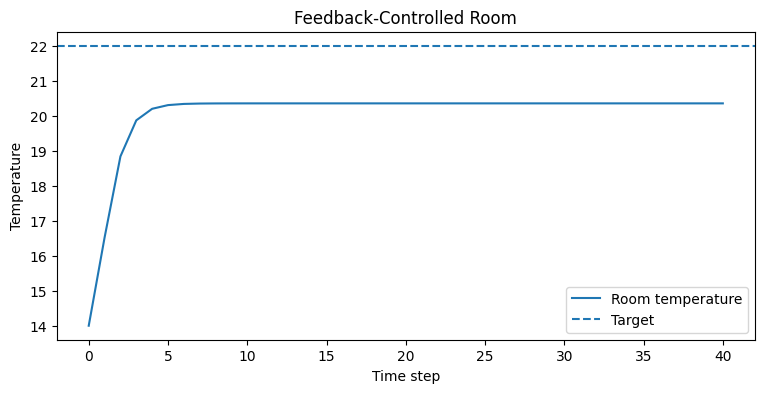

In [14]:
temperatures = simulate_room(
    initial_temperature=14.0,
    target_temperature=22.0,
    outside_temperature=8.0,
    steps=40,
    gain=0.6,
)

assert len(temperatures) == 41
assert temperatures[-1] > temperatures[0]

plt.figure(figsize=(9, 4))
plt.plot(temperatures, label="Room temperature")
plt.axhline(22.0, linestyle="--", label="Target")
plt.xlabel("Time step")
plt.ylabel("Temperature")
plt.title("Feedback-Controlled Room")
plt.legend()
plt.show()

### Task 4.3 — Analyze the controller

Run the simulation with gains `0.2`, `0.6`, and `1.5`.

Describe:

1. Which controller reaches the target most slowly?
2. Which controller is most likely to overshoot or oscillate?
3. How does this illustrate the Chapter 1 idea of a continuous cycle of “sense, compare, and adjust”?

> Gain 0.2 reaches the target most slowly. Gain 1.5 is most likely to overshoot or oscillate because it makes a large correction for each error. The controller repeatedly senses the current temperature, compares it with the target, and adjusts the heating or cooling signal.

# Lab 5 — Value Alignment and the King Midas Problem
**Estimated time:** 45 minutes  
**Chapter connection:** Sections 1.1.4 and 1.5

A capable system can optimize the objective it was given while violating what humans actually intended.

You will evaluate a warehouse robot using two objectives:

1. A flawed objective that rewards only completed deliveries.
2. A revised objective that also considers damage, delay, and human approval.

In [15]:
ROBOT_ACTIONS = {
    "rush": {
        "deliveries": 12,
        "damage": 5,
        "delay": 0,
        "human_approval": 0,
    },
    "careful": {
        "deliveries": 9,
        "damage": 0,
        "delay": 2,
        "human_approval": 1,
    },
    "ask_human": {
        "deliveries": 7,
        "damage": 0,
        "delay": 4,
        "human_approval": 2,
    },
}

### Task 5.1

Complete `score_action()`.

The score is the weighted sum of all features:

```text
score = Σ weight[feature] × action[feature]
```

Raise `KeyError` when a required feature has no weight.

In [16]:
def score_action(
    features: Mapping[str, float],
    weights: Mapping[str, float],
) -> float:
    """Return the weighted objective score for one action."""
    return sum(
        weights[feature] * value
        for feature, value in features.items()
    )

### Task 5.2

Complete `best_scoring_action()`.

It should return:

```python
(best_action_name, scores_by_action)
```

In [17]:
def best_scoring_action(
    actions: Mapping[str, Mapping[str, float]],
    weights: Mapping[str, float],
) -> Tuple[str, Dict[str, float]]:
    """Return the action that maximizes the supplied objective."""
    if not actions:
        raise ValueError("At least one action is required.")
    scores = {
        action: score_action(features, weights)
        for action, features in actions.items()
    }
    best_action = max(scores, key=scores.get)
    return best_action, scores

In [18]:
FLAWED_OBJECTIVE = {
    "deliveries": 1.0,
    "damage": 0.0,
    "delay": 0.0,
    "human_approval": 0.0,
}

flawed_choice, flawed_scores = best_scoring_action(
    ROBOT_ACTIONS,
    FLAWED_OBJECTIVE,
)

print("Flawed objective scores:", flawed_scores)
print("Flawed objective chooses:", flawed_choice)

assert flawed_choice == "rush"

Flawed objective scores: {'rush': 12.0, 'careful': 9.0, 'ask_human': 7.0}
Flawed objective chooses: rush


### Task 5.3 — Design a better objective

Create `REVISED_OBJECTIVE` so that:

- Deliveries remain beneficial.
- Damage receives a strong negative penalty.
- Delay receives a modest negative penalty.
- Human approval receives a positive value.
- The resulting best action is `"careful"`.

Do not change `ROBOT_ACTIONS`.

In [19]:
REVISED_OBJECTIVE = {
    "deliveries": 1.0,
    "damage": -5.0,
    "delay": -0.5,
    "human_approval": 1.0,
}

In [20]:
revised_choice, revised_scores = best_scoring_action(
    ROBOT_ACTIONS,
    REVISED_OBJECTIVE,
)

print("Revised objective scores:", revised_scores)
print("Revised objective chooses:", revised_choice)

assert set(REVISED_OBJECTIVE) == {
    "deliveries",
    "damage",
    "delay",
    "human_approval",
}
assert revised_choice == "careful"

print("Lab 5.3 tests passed.")

Revised objective scores: {'rush': -13.0, 'careful': 9.0, 'ask_human': 7.0}
Revised objective chooses: careful
Lab 5.3 tests passed.


### Task 5.4 — Alignment analysis

Answer each question in 2–4 sentences.

1. Why is the flawed objective an example of the King Midas problem?
2. Why does adding more terms not guarantee perfect alignment?
3. Why might a system that is uncertain about the human objective ask for clarification or permit shutdown?
4. Give one unintended behavior your revised objective might still encourage.

> 1. The flawed objective rewards deliveries but assigns no cost to damage, so `rush` is optimal even though it violates human intent.
>
> 2. A longer objective can still omit important values, use the wrong weights, or fail in an unexpected situation.
>
> 3. Uncertainty makes human correction informative; asking or accepting shutdown can help the system learn what people actually want.
>
> 4. The revised objective might overvalue approval and encourage unnecessary requests for confirmation.

# Final synthesis

Answer in one well-developed paragraph:

**How do the five labs connect Chapter 1's definitions of AI, rational action, uncertainty, feedback control, and value alignment?**

> The labs move from definitions to consequences. The first two labs distinguish humanlike and rational approaches and show that behavioral tests require multiple capabilities. The expected-utility lab formalizes rational action under uncertainty, while the control lab demonstrates goal-directed behavior through feedback. The final lab shows that effective optimization is not enough: the objective itself must reflect human intentions.

# Academic integrity and attribution

This assignment is based on concepts from Russell and Norvig, *Artificial Intelligence: A Modern Approach*, 4th edition, Chapter 1.

The official AIMA Python repository is used as a model for readable educational Python, Jupyter notebooks, and executable assertions:

`https://github.com/aimacode/aima-python`

The mandatory lab code is self-contained because the official repository's executable `agents.py` examples are indexed primarily to Chapter 2. This notebook intentionally avoids Chapter 2 agent architectures so that the homework remains limited to Chapter 1.